# **1/ Tạo dữ liệu mẫu**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(21)
from matplotlib.backends.backend_pdf import PdfPages

means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)

# Điểm của lớp 0 lấn sang vùng lớp 1
X0 = np.vstack([X0, [3.2, 1.8]])
# Điểm của lớp 1 lấn sâu sang vùng lớp 0
X1[-1, :] = [2.3, 2.2]


X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, X0.shape[0])), -1*np.ones((1, X1.shape[0]))), axis = 1)
N = X0.shape[0]


# **2/ Tính nghiệm bằng sklearn**

In [ ]:
from sklearn.svm import SVC
C=100
clf = SVC(kernel = 'linear', C = C)
clf.fit(X.T, y.ravel())

w_sklearn = clf.coef_.reshape(-1, 1)
b_sklearn = clf.intercept_[0]
print(w_sklearn.T, b_sklearn)

[[-1.19741718  1.13839674]] 1.9895377260368987


# **3/ Tìm nghiệm bằng giải bài toán đối ngẫu**

In [ ]:
from cvxopt import matrix, solvers
n_samples = X.shape[1]

V = np.concatenate((X0.T, -X1.T), axis = 1)
P = matrix(V.T.dot(V))

q = matrix(-np.ones((n_samples, 1)))

G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
h = matrix(np.vstack((np.zeros((n_samples, 1)), C*np.ones((n_samples, 1)))))

A = matrix(y.reshape((1, -1)))
b = matrix(np.zeros((1, 1)))

solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)

l = np.array(sol['x'])
print('lambda = \n', l)

lambda = 
 [[4.90384507e-07]
 [1.11424767e-06]
 [7.80290701e+01]
 [5.34277177e-07]
 [4.06158811e-07]
 [2.96272436e-07]
 [5.78129278e-07]
 [5.25327780e-07]
 [4.02400939e-07]
 [6.43862306e-07]
 [9.99999989e+01]
 [3.13614686e-07]
 [2.18503805e-07]
 [6.13531549e-07]
 [2.29086500e-06]
 [1.15912013e-06]
 [4.69530238e+01]
 [2.20900496e-07]
 [3.10760436e+01]
 [1.95935575e-06]
 [9.99999997e+01]]


In [ ]:
S = np.where(l > 1e-5)[0]
S2 = np.where(l < .999*C)[0]

M = [val for val in S if val in S2]

XT = X.T
VS = V[:, S]
lS = l[S]

yM = y[0, M]
XM = XT[M, :]

w_dual = VS.dot(lS).reshape(-1, 1)
b_dual = np.mean(yM - w_dual.T.dot(XM.T))
print(w_dual.T, b_dual)

[[-1.19761491  1.13851725]] 1.9899674444754112


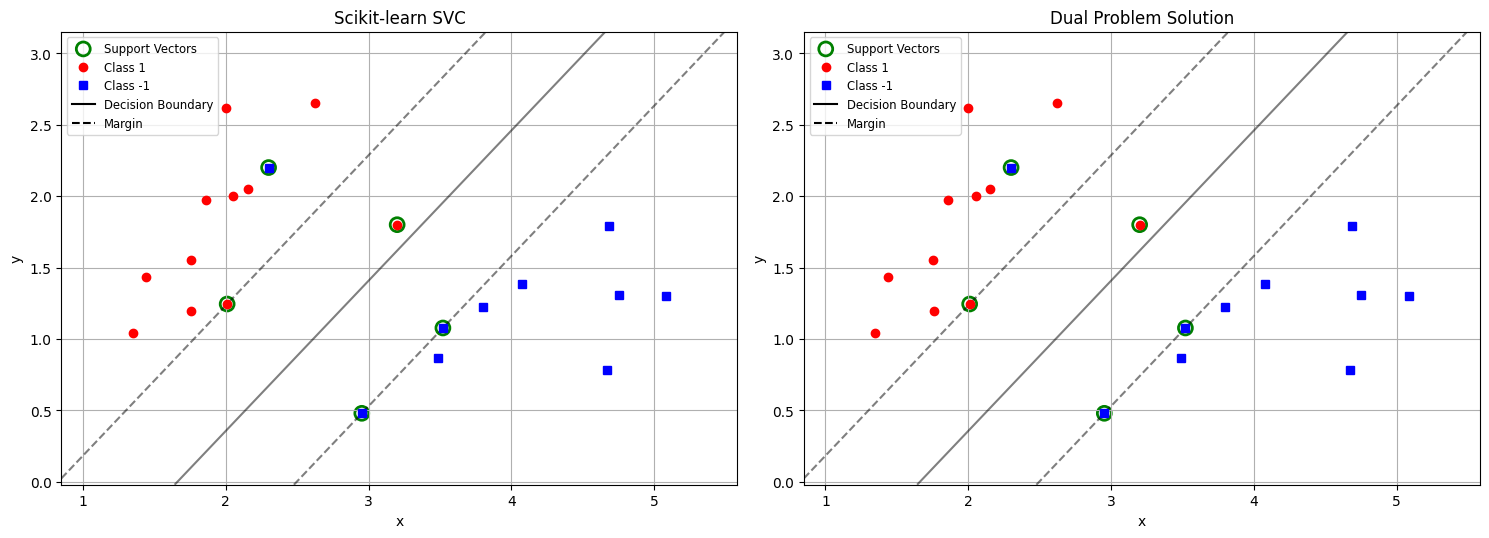

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist # Included for consistency with original data gen
from matplotlib.backends.backend_pdf import PdfPages # Included for consistency with original data gen
from sklearn.svm import SVC
from cvxopt import matrix, solvers

# --- 1. Tạo dữ liệu mẫu (from cell 4L7BrGXJ_l_S) ---
np.random.seed(21)

means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)

# Điểm của lớp 0 lấn sang vùng lớp 1
X0 = np.vstack([X0, [3.2, 1.8]])
# Điểm của lớp 1 lấn sâu sang vùng lớp 0
X1[-1, :] = [2.3, 2.2]

X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, X0.shape[0])), -1*np.ones((1, X1.shape[0]))), axis = 1)
# N = X0.shape[0] # N was redefined, but not used here, X.shape[1] is better for total samples

# --- 2. Tính nghiệm bằng sklearn (from cell 3pOi-jEC_opT) ---
C=100
clf = SVC(kernel = 'linear', C = C)
# Transpose X to (20, 2) and flatten y to (20,)
clf.fit(X.T, y.ravel())

w_sklearn = clf.coef_.reshape(-1, 1)
b_sklearn = clf.intercept_[0]
# print(w_sklearn.T, b_sklearn)

# --- 3. Tìm nghiệm bằng giải bài toán đối ngẫu (from cell w16EWcWiAVvE and kj164aAAAY7N) ---

# Xác định tổng số điểm dữ liệu thực tế
n_samples = X.shape[1]

V = np.concatenate((X0.T, -X1.T), axis = 1)
P = matrix(V.T.dot(V))

q = matrix(-np.ones((n_samples, 1)))

# G và h tương ứng với ràng buộc 0 <= lambda <= C
G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
h = matrix(np.vstack((np.zeros((n_samples, 1)), C*np.ones((n_samples, 1)))))

# A và b tương ứng với ràng buộc sum(lambda_i * y_i) = 0
A = matrix(y.reshape((1, -1)))
b = matrix(np.zeros((1, 1)))

solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)

l = np.array(sol['x'])
# print('lambda = \n', l)

S = np.where(l > 1e-5)[0]
S2 = np.where(l < .999*C)[0]

M = [val for val in S if val in S2]

XT = X.T
VS = V[:, S]
lS = l[S]

yM = y[0, M]
XM = XT[M, :]

w_dual = VS.dot(lS).reshape(-1, 1)
b_dual = np.mean(yM - w_dual.T.dot(XM.T))
# print(w_dual.T, b_dual)

# --- Plotting Code ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Changed to 1 row, 2 columns

# Get global limits from the data to ensure lines are not truncated
x_min, x_max = X[0, :].min() - .5, X[0, :].max() + .5
y_min, y_max = X[1, :].min() - .5, X[1, :].max() + .5

# Create a consistent meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
xy = np.vstack([xx.ravel(), yy.ravel()]).T

# --- 1. Scikit-learn SVC ---
Z1 = clf.decision_function(xy).reshape(xx.shape)
axes[0].contour(xx, yy, Z1, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
axes[0].scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='g', linewidth=2, label='Support Vectors')
axes[0].set_title('Scikit-learn SVC')

# --- 2. Dual Problem ---
Z2 = (w_dual[0] * xx + w_dual[1] * yy + b_dual)
axes[1].contour(xx, yy, Z2, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
axes[1].scatter(XT[S, 0], XT[S, 1], s=100, facecolors='none', edgecolors='g', linewidth=2, label='Support Vectors')
axes[1].set_title('Dual Problem Solution')

# Common plotting elements and Legend fix
for ax in axes:
    ax.plot(X0[:, 0], X0[:, 1], 'ro', markersize=6, label='Class 1')
    ax.plot(X1[:, 0], X1[:, 1], 'bs', markersize=6, label='Class -1')
    # Add dummy lines for legend
    ax.plot([], [], 'k-', label='Decision Boundary')
    ax.plot([], [], 'k--', label='Margin')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()